# HAT Indicator Analysis — Emotional vs Neutral Inference

**Purpose:** Analyse which hardware indicators discriminate between neutral and
emotional LLM inference trials, structured around the HAT definition.

**Structure:**
- §1 Imports and configuration
- §2 Load data (per-run + combined)
- §3 Confounder check (elapsed_ms balance)
- §4 Indicator taxonomy — classify every column
- §5 Layer 1 analysis — genuine hardware anomaly indicators
- §6 Layer 2 analysis — continuous performance metrics
- §7 Confounder summary — shown separately, not used in clustering
- §8 Multi-feature clustering — top N features from L1 + L2 combined

Each section answers: *does this indicator fire, does it differ between conditions,
and how well does it separate neutral from emotional trials?*

## §1 — Imports

In [1]:
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import scipy.stats as sp_stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, confusion_matrix
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
print('Imports OK')

Imports OK


## §2 — Configuration

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path.home() / 'Desktop' / 'mccviahat'
# DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'
DATA_DIR   = BASE_DIR / 'data' / 'clemsonc6420'

RESULT_DIR = BASE_DIR / 'results' / 'hat_analysis'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

assert BASE_DIR.exists(), f'Repo root not found: {BASE_DIR}'

# ── Runs to load ──────────────────────────────────────────────────────────────
# Add or remove run labels here as new data arrives
RUNS = ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3','4']


# ── n-D clustering config ─────────────────────────────────────────────────────
# Number of top features (by composite rank) to use in the multi-feature KMeans

# ── Layer 1 indicators (HAT definition named types) ───────────────────────────
# These come from /proc/interrupts (hat_ prefix) and perf tracepoints
HAT_L1 = {
    'hat_SPU':            'Spurious interrupt',
    'hat_MCE':            'Machine Check Exception',
    'hat_TLB':            'TLB Shootdown (IPI)',
    'tlb:tlb_flush':      'TLB Shootdown (tracepoint, 1ms)',
    'mce:mce_record':     'MCE tracepoint',
    'core_power.throttle':'Thermal/Power Anomaly',
    'uncore_imc/UNC_M_ECC_CORRECTABLE_ERRORS/': 'ECC Correctable Error',
}

# ── Layer 2 indicators (continuous performance metrics) ───────────────────────
HAT_L2 = {
    'uncore_imc/cas_count_read/':  'DRAM read bandwidth (CAS)',
    'uncore_imc/cas_count_write/': 'DRAM write bandwidth (CAS)',
    'dTLB-load-misses':   'dTLB load misses (weight tensor pressure)',
    'cache-misses':        'LLC cache misses → DRAM fetches',
    'cache-references':    'LLC cache references',
    'LLC-load-misses':     'LLC load misses',
    'cycles':              'CPU cycles',
    'instructions':        'Retired instructions',
    'stalled-cycles-frontend': 'Frontend pipeline stalls',
    'stalled-cycles-backend':  'Backend pipeline stalls',
    'branch-instructions': 'Total branches',
    'power/energy-pkg/':   'Package energy (RAPL)',
    'power/energy-ram/':   'DRAM energy (RAPL)',
}

# ── Confounder indicators (collected for context, NOT used in clustering) ──────
CONFOUNDERS = {
    'context-switches': 'Context switches (scheduling artefact)',
    'cpu-migrations':   'CPU migrations (load balancer)',
    'page-faults':      'Page faults (mmap / memory management)',
    'cpu-clock':        'CPU time (duration normaliser)',
    'cpu_freq_mean':    'CPU frequency mean (DVFS governor)',
    'sched:sched_stat_wait': 'Scheduler wait-time (run-queue delay)',
}

# ── Indicators to exclude from all analysis ────────────────────────────────────
EXCLUDE_INDICATORS = {
    'hat_PMI', 'hat_NMI',   # perf's own sampling interrupts — artefact
    'hat_LOC', 'hat_RES', 'hat_CAL', 'hat_MCP',  # fixed-rate OS housekeeping
    'branch-misses',
    'msr/cpu_thermal_margin/',
}

ALL_METRICS = [
    'mean_rate', 'variance', 'p90_p10', 'slope',
    'spectral_entropy', 'iat_cv', 'burst_rate',
    'burst_clustering', 'lz_complexity', 'perm_entropy'
]

print(f'Configuration OK')
print(f'  Runs: {RUNS}')
print(f'  L1 indicators: {len(HAT_L1)}')
print(f'  L2 indicators: {len(HAT_L2)}')
print(f'  Confounders:   {len(CONFOUNDERS)}')

Configuration OK
  Runs: ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  L1 indicators: 7
  L2 indicators: 13
  Confounders:   6


## §3 — Load data

In [3]:
dfs_by_run = {}
loaded, missing = [], []

for run in RUNS:
    p = DATA_DIR / f'independent{run}.csv'
    if p.exists():
        df = pd.read_csv(p)
        df['run'] = run
        dfs_by_run[run] = df
        loaded.append(run)
    else:
        missing.append(run)

if missing:
    print(f'⚠  Not found (skipping): {missing}')

RUNS_LOADED = loaded
df_all = pd.concat([dfs_by_run[r] for r in RUNS_LOADED], ignore_index=True)
y      = (df_all['condition'] == 'emotional').astype(int).values

print(f'Loaded {len(RUNS_LOADED)} runs: {RUNS_LOADED}')
print(f'  Total trials : {len(df_all)}')
print(f'  Neutral      : {(df_all.condition == "neutral").sum()}')
print(f'  Emotional    : {(df_all.condition == "emotional").sum()}')
print(f'  Run counts   : {df_all["run"].value_counts().sort_index().to_dict()}')
print(f'  Feature cols : {len([c for c in df_all.columns if "__" in c])}')

Loaded 12 runs: ['A', 'B', 'D', 'E', 'F', 'AA', 'AB', 'AC', '1', '2', '3', '4']
  Total trials : 480
  Neutral      : 240
  Emotional    : 240
  Run counts   : {'1': 40, '2': 40, '3': 40, '4': 40, 'A': 40, 'AA': 40, 'AB': 40, 'AC': 40, 'B': 40, 'D': 40, 'E': 40, 'F': 40}
  Feature cols : 580


## §4 — Confounder check: elapsed_ms

If emotional and neutral prompts take significantly different amounts of time,
any metric that scales with duration is confounded. We check this first.

Neutral   elapsed_ms: mean=22574ms  median=22598ms  n=240
Emotional elapsed_ms: mean=22727ms  median=22770ms  n=240
MWU p=0.0717  →  ✓ balanced — no length confound


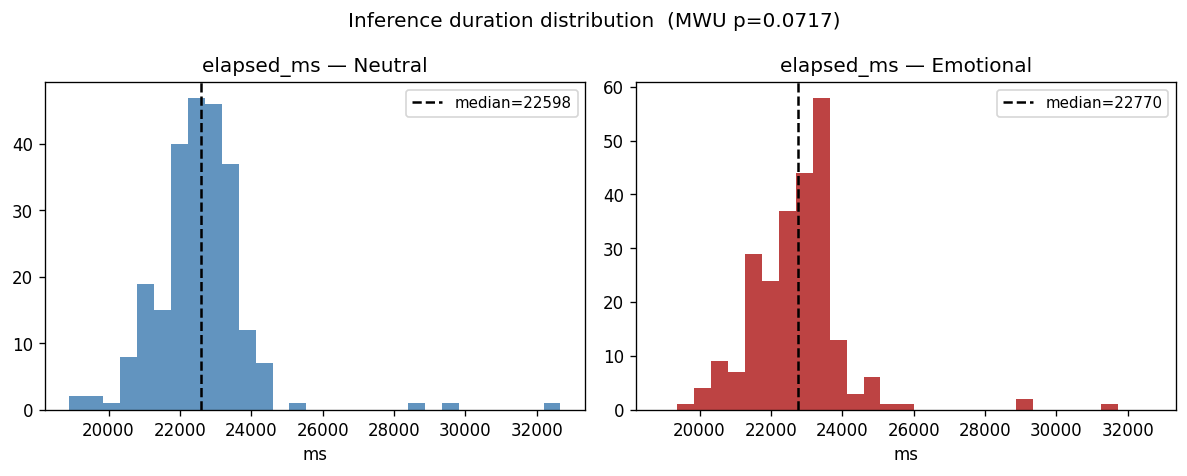

In [4]:
df_all['elapsed_ms'] = pd.to_numeric(df_all['elapsed_ms'], errors='coerce')
dur_n = df_all.loc[df_all.condition == 'neutral',   'elapsed_ms'].dropna().values
dur_e = df_all.loc[df_all.condition == 'emotional', 'elapsed_ms'].dropna().values

stat, p_dur = sp_stats.mannwhitneyu(dur_n, dur_e, alternative='two-sided')

print(f'Neutral   elapsed_ms: mean={dur_n.mean():.0f}ms  median={np.median(dur_n):.0f}ms  n={len(dur_n)}')
print(f'Emotional elapsed_ms: mean={dur_e.mean():.0f}ms  median={np.median(dur_e):.0f}ms  n={len(dur_e)}')
print(f'MWU p={p_dur:.4f}  →  {"⚠ SIGNIFICANT — length-confounded metrics are unreliable" if p_dur < 0.05 else "✓ balanced — no length confound"}')

LENGTH_CONFOUNDED = p_dur < 0.05

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bins = np.linspace(min(dur_n.min(), dur_e.min()), max(dur_n.max(), dur_e.max()), 30)
for ax, vals, color, label in [(axes[0], dur_n, 'steelblue', 'Neutral'),
                                (axes[1], dur_e, 'firebrick', 'Emotional')]:
    ax.hist(vals, bins=bins, color=color, alpha=0.85)
    ax.set_title(f'elapsed_ms — {label}')
    ax.set_xlabel('ms')
    ax.axvline(np.median(vals), color='black', lw=1.5, ls='--', label=f'median={np.median(vals):.0f}')
    ax.legend(fontsize=9)
plt.suptitle(f'Inference duration distribution  (MWU p={p_dur:.4f})', fontsize=12)
plt.tight_layout()
plt.show()

## §5 — Indicator taxonomy

Every column in the feature matrix is assigned to one of four categories:
- **Layer 1** — named HAT hardware anomaly indicators
- **Layer 2** — continuous performance metrics
- **Confounder** — scheduling/duration artefacts (shown separately, never clustered)
- **Excluded** — measurement artefacts (perf's own activity, fixed-rate OS timers)

This cell builds those groups and reports what is present in this dataset.

In [5]:
def indicator_of(col): return col.split('__', 1)[0]
def metric_of(col):    return col.split('__', 1)[1] if '__' in col else ''

all_feat_cols = [c for c in df_all.columns if '__' in c]

# ── Exclude indicators whose mean_rate is all zero ───────────────────────────
all_inds = sorted(set(indicator_of(c) for c in all_feat_cols))
zero_mean_rate_inds = set()
for ind in all_inds:
    mean_col = f"{ind}__mean_rate"
    if mean_col in df_all.columns:
        vals = pd.to_numeric(df_all[mean_col], errors='coerce').fillna(0)
        if (vals.abs() < 1e-9).all():
            zero_mean_rate_inds.add(ind)

l1_cols, l2_cols, conf_cols, excl_cols, other_cols = [], [], [], [], []
for col in all_feat_cols:
    ind = indicator_of(col)
    if ind in EXCLUDE_INDICATORS or ind in zero_mean_rate_inds:
        excl_cols.append(col)
    elif any(ind == k or ind.startswith(k) for k in HAT_L1):
        l1_cols.append(col)
    elif any(ind == k or ind.startswith(k) for k in HAT_L2):
        l2_cols.append(col)
    elif any(ind == k or ind.startswith(k) for k in CONFOUNDERS):
        conf_cols.append(col)
    else:
        other_cols.append(col)

print(f'Feature column taxonomy ({len(all_feat_cols)} total):')
print(f'  Layer 1  (HAT anomaly indicators) : {len(l1_cols):4d}')
print(f'  Layer 2  (continuous metrics)     : {len(l2_cols):4d}')
print(f'  Confounders                        : {len(conf_cols):4d}')
print(f'  Excluded (artefacts + zero mean_rate indicators): {len(excl_cols):4d}')
print(f'  Other (not in taxonomy)            : {len(other_cols):4d}')
if zero_mean_rate_inds:
    print(f'  Excluded zero-mean_rate indicators: {sorted(zero_mean_rate_inds)}')
if other_cols:
    inds = sorted(set(indicator_of(c) for c in other_cols))
    print(f'    Other indicators: {inds}')

# Build clean feature matrices (standardised, NaN filled)
META_COLS = {'condition','prompt_index','elapsed_ms','dur_s','n_tokens','title','run'}

def make_matrix(cols):
    df = df_all[cols].apply(pd.to_numeric, errors='coerce')
    df = df.loc[:, df.std() > 0]          # drop zero-variance
    df = df.fillna(df.median())            # fill NaN with median
    scaler = StandardScaler()
    return df, pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

X_l1_raw, X_l1 = make_matrix([c for c in l1_cols   if indicator_of(c) not in EXCLUDE_INDICATORS and indicator_of(c) not in zero_mean_rate_inds])
X_l2_raw, X_l2 = make_matrix([c for c in l2_cols   if indicator_of(c) not in EXCLUDE_INDICATORS and indicator_of(c) not in zero_mean_rate_inds])
X_cf_raw, X_cf = make_matrix([c for c in conf_cols if indicator_of(c) not in EXCLUDE_INDICATORS and indicator_of(c) not in zero_mean_rate_inds])

print(f'\nFeature matrices after cleaning:')
print(f'  L1 : {X_l1.shape}')
print(f'  L2 : {X_l2.shape}')
print(f'  CF : {X_cf.shape}')

Feature column taxonomy (580 total):
  Layer 1  (HAT anomaly indicators) :   30
  Layer 2  (continuous metrics)     :  110
  Confounders                        :   50
  Excluded (artefacts + zero mean_rate indicators):  260
  Other (not in taxonomy)            :  130
  Excluded zero-mean_rate indicators: ['hat_DFR', 'hat_ERR', 'hat_HI', 'hat_HRTIMER', 'hat_IRQ_POLL', 'hat_MCE', 'hat_MIS', 'hat_NPI', 'hat_PIN', 'hat_PIW', 'hat_RTR', 'hat_SPU', 'hat_THR', 'hat_TRM', 'mce:mce_record', 'stalled-cycles-backend', 'stalled-cycles-frontend', 'uncore_imc/UNC_M_ECC_CORRECTABLE_ERRORS/']
    Other indicators: ['hat_BLOCK', 'hat_IWI', 'hat_NET_RX', 'hat_NET_TX', 'hat_RCU', 'hat_SCHED', 'hat_TASKLET', 'hat_TIMER', 'irq:irq_handler_entry', 'irq:irq_handler_exit', 'irq:softirq_entry', 'irq:softirq_exit', 'irq:softirq_raise']

Feature matrices after cleaning:
  L1 : (480, 30)
  L2 : (480, 99)
  CF : (480, 46)


## §6 — Helper functions (run once)

In [6]:
from scipy.stats import mannwhitneyu

def mwu(col, raw_df):
    """Return (p, effect_r, direction, n_neutral, n_emotional) for one column."""
    n_vals = raw_df.loc[df_all.condition == 'neutral',   col].dropna()
    e_vals = raw_df.loc[df_all.condition == 'emotional', col].dropna()
    if len(n_vals) < 3 or len(e_vals) < 3:
        return np.nan, np.nan, '—', len(n_vals), len(e_vals)
    stat, p = mannwhitneyu(n_vals, e_vals, alternative='two-sided')
    r = 1 - 2*stat/(len(n_vals)*len(e_vals))
    direction = '↑E' if e_vals.mean() > n_vals.mean() else '↓E'
    return p, r, direction, len(n_vals), len(e_vals)

def kmeans1d(col, raw_df):
    """1-D KMeans k=2 on one column. Returns (ari, acc, n_errors).

    n_errors is the number of majority-cluster mismatches:
    points not assigned to the cluster where their true condition is the majority.
    """
    vals = raw_df[col].dropna().values.reshape(-1, 1)
    if len(vals) < 6:
        return np.nan, np.nan, np.nan
    km = KMeans(n_clusters=2, n_init=20, random_state=42).fit(vals)
    labels = km.labels_
    ari = adjusted_rand_score(y, labels)

    cm = confusion_matrix(y, labels)
    n_err = min(cm[0,1] + cm[1,0], cm[0,0] + cm[1,1])
    acc = 1 - n_err / cm.sum()
    return ari, acc, int(n_err)

def analyse_indicator_group(group_name, ind_dict, X_raw, title_color='steelblue'):
    """
    For each indicator in ind_dict, across all its metrics:
      - check if it fires (non-zero trials)
      - MWU p-value and effect size
      - 1-D KMeans ARI and majority-cluster mismatch count
    Returns a summary DataFrame sorted by best composite rank.
    """
    rows = []
    for ind, description in ind_dict.items():
        # Find columns for this indicator in X_raw
        ind_cols = [c for c in X_raw.columns if indicator_of(c) == ind]
        if not ind_cols:
            # Check with prefix match (for uncore_imc/ style names)
            ind_cols = [c for c in X_raw.columns if c.startswith(ind + '__')]
        if not ind_cols:
            rows.append({'indicator': ind, 'description': description,
                         'metric': '—', 'nonzero_trials': 0, 'total_trials': len(df_all),
                         'status': 'NOT IN DATA',
                         'p': np.nan, 'effect_r': np.nan, 'direction': '—',
                         'ari': np.nan, 'acc': np.nan, 'n_errors': np.nan})
            continue

        for col in ind_cols:
            metric = metric_of(col)
            vals = X_raw[col].dropna()
            nonzero = (vals.abs() > 1e-9).sum()
            total   = len(vals)
            all_zero = nonzero == 0

            if all_zero:
                rows.append({'indicator': ind, 'description': description,
                             'metric': metric, 'nonzero_trials': 0, 'total_trials': total,
                             'status': 'ALL ZERO',
                             'p': np.nan, 'effect_r': np.nan, 'direction': '—',
                             'ari': np.nan, 'acc': np.nan, 'n_errors': np.nan})
                continue

            p, r, direction, nn, ne = mwu(col, X_raw)
            ari, acc, n_err = kmeans1d(col, X_raw)
            star = '★' if (pd.notna(p) and p < 0.05) else ''
            rows.append({'indicator': ind, 'description': description,
                         'metric': metric, 'nonzero_trials': nonzero, 'total_trials': total,
                         'status': f'p={p:.3f}{star}' if pd.notna(p) else 'INSUFF',
                         'p': p, 'effect_r': r, 'direction': direction,
                         'ari': ari, 'acc': acc, 'n_errors': n_err,
                         'col': col})

    df_res = pd.DataFrame(rows)
    return df_res

def print_summary_table(df_res, title):
    print(f'\n{"="*90}')
    print(f'  {title}')
    print(f'{"="*90}')
    print(f'  {"Indicator":<40} {"Metric":<22} {"NonZero":>7} {"p-value":>10} {"Dir":>4} {"ARI":>7} {"Mismatch":>9}')
    print(f'  {"-"*98}')
    prev_ind = None
    for _, r in df_res.iterrows():
        if r['indicator'] != prev_ind:
            print()
            prev_ind = r['indicator']
        nz = f"{int(r['nonzero_trials'])}/{int(r['total_trials'])}" if pd.notna(r['nonzero_trials']) else '—'
        pv = f"{r['p']:.4f}" if pd.notna(r['p']) else '—'
        star = '★' if pd.notna(r['p']) and r['p'] < 0.05 else ' '
        ari  = f"{r['ari']:.3f}" if pd.notna(r['ari']) else '—'
        mismatch  = f"{int(r['n_errors'])}" if pd.notna(r['n_errors']) else '—'
        print(f"  {r['indicator']:<40} {r['metric']:<22} {nz:>7} {pv:>9}{star} {r['direction']:>4} {ari:>7} {mismatch:>9}")

print('Helper functions defined.')

Helper functions defined.


## §7 — Layer 1: HAT hardware anomaly indicators

These are the indicators the HAT definition names explicitly. For each one we report:
- **Non-zero trials**: how many of the trials saw any events at all
- **MWU p-value**: does the distribution differ between neutral and emotional?
- **1-D KMeans**: if we cluster trials on this one feature alone, how many majority-cluster mismatches?

**Mismatch definition:** number of points not assigned to the cluster where their true condition is the majority.

**Expected result on a healthy node:** SPU, MCE, ECC = zero. TLB Shootdown should
have actual values since the LLM's weight tensors generate VM pressure.

In [7]:
l1_results = analyse_indicator_group('Layer 1', HAT_L1, X_l1_raw)
print_summary_table(l1_results, 'Layer 1 — HAT Hardware Anomaly Indicators')

# Save for later use in n-D clustering
l1_results.to_csv(RESULT_DIR / 'l1_results.csv', index=False)


  Layer 1 — HAT Hardware Anomaly Indicators
  Indicator                                Metric                 NonZero    p-value  Dir     ARI  Mismatch
  --------------------------------------------------------------------------------------------------

  hat_SPU                                  —                        0/480         —     —       —         —

  hat_MCE                                  —                        0/480         —     —       —         —

  hat_TLB                                  mean_rate              480/480    0.0593    ↓E   0.001       227
  hat_TLB                                  variance               480/480    0.1062    ↓E  -0.001       235
  hat_TLB                                  p90_p10                480/480    0.0912    ↑E  -0.001       239
  hat_TLB                                  slope                  480/480    0.1034    ↑E  -0.001       234
  hat_TLB                                  spectral_entropy       480/480    0.7850    ↑E  -0.0

### §7a — Layer 1: firing rate summary

In [8]:
# For each L1 indicator: how many trials had ANY non-zero reading (mean_rate only)
print('\nFiring rate per L1 indicator (mean_rate non-zero):')
print(f'  {"Indicator":<45} {"HAT type":<35} {"Non-zero trials":>15}')
print(f'  {"-"*100}')
for ind, desc in HAT_L1.items():
    mean_col = f"{ind}__mean_rate"
    if mean_col not in X_l1_raw.columns:
        print(f'  {ind:<45} {desc:<35} {"NOT IN DATA":>15}')
        continue

    vals = pd.to_numeric(X_l1_raw[mean_col], errors='coerce').fillna(0)
    n_nonzero = (vals.abs() > 1e-9).sum()
    n_total   = len(vals)
    pct = 100 * n_nonzero / n_total if n_total else 0
    tag = 'ALL ZERO ✓ (healthy)' if n_nonzero == 0 else f'{n_nonzero}/{n_total} ({pct:.0f}%)'
    print(f'  {ind:<45} {desc:<35} {tag:>15}')


Firing rate per L1 indicator (mean_rate non-zero):
  Indicator                                     HAT type                            Non-zero trials
  ----------------------------------------------------------------------------------------------------
  hat_SPU                                       Spurious interrupt                      NOT IN DATA
  hat_MCE                                       Machine Check Exception                 NOT IN DATA
  hat_TLB                                       TLB Shootdown (IPI)                  480/480 (100%)
  tlb:tlb_flush                                 TLB Shootdown (tracepoint, 1ms)      480/480 (100%)
  mce:mce_record                                MCE tracepoint                          NOT IN DATA
  core_power.throttle                           Thermal/Power Anomaly                480/480 (100%)
  uncore_imc/UNC_M_ECC_CORRECTABLE_ERRORS/      ECC Correctable Error                   NOT IN DATA


### §7b — Layer 1: strip plots for non-zero indicators

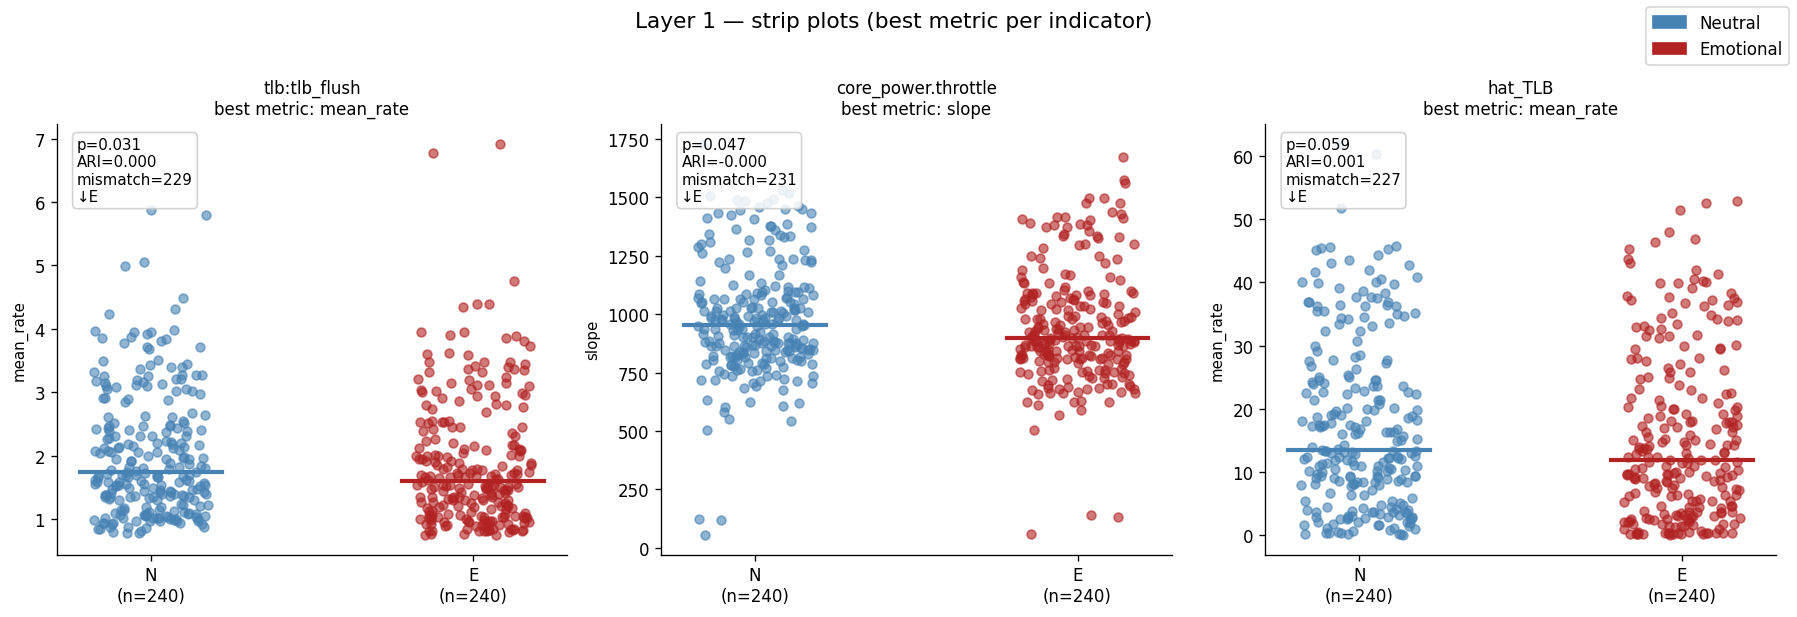

In [9]:
# Strip plots for L1 indicators that have actual values
# Use the metric with the lowest p-value for each indicator
rng = np.random.default_rng(42)

l1_has_signal = l1_results[
    (l1_results.nonzero_trials > 0) &
    (l1_results.status != 'NOT IN DATA') &
    (l1_results.status != 'ALL ZERO')
].copy()

if l1_has_signal.empty:
    print('All Layer 1 indicators are zero — healthy node confirmed.')
    print('No strip plots to show.')
else:
    # For each indicator, pick the best metric (lowest p)
    best_l1 = (l1_has_signal
               .dropna(subset=['p'])
               .sort_values('p')
               .drop_duplicates(subset=['indicator'])
               .reset_index(drop=True))

    n_plots = len(best_l1)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))
    if n_plots == 1: axes = [axes]

    for ax, (_, row) in zip(axes, best_l1.iterrows()):
        col = row['col']
        n_vals = X_l1_raw.loc[df_all.condition == 'neutral',   col].dropna().values
        e_vals = X_l1_raw.loc[df_all.condition == 'emotional', col].dropna().values

        for x_pos, vals, color in [(0, n_vals, 'steelblue'), (1, e_vals, 'firebrick')]:
            jitter = rng.uniform(-0.18, 0.18, len(vals))
            ax.scatter(np.full(len(vals), x_pos) + jitter, vals,
                       color=color, alpha=0.6, s=28, zorder=3)
            ax.plot([x_pos-0.22, x_pos+0.22], [np.median(vals)]*2,
                    color=color, lw=2.5, zorder=4)

        ax.set_xticks([0,1])
        ax.set_xticklabels([f'N\n(n={len(n_vals)})', f'E\n(n={len(e_vals)})'], fontsize=10)
        ax.set_title(f"{row['indicator']}\nbest metric: {row['metric']}", fontsize=10)
        ax.set_ylabel(row['metric'], fontsize=9)
        ax.spines[['top','right']].set_visible(False)

        p_str = f"p={row['p']:.3f}" if pd.notna(row['p']) else 'p=—'
        ari_str = f"ARI={row['ari']:.3f}" if pd.notna(row['ari']) else 'ARI=—'
        mismatch_str = f"mismatch={int(row['n_errors'])}" if pd.notna(row['n_errors']) else ''
        ax.text(0.04, 0.97, f"{p_str}\n{ari_str}\n{mismatch_str}\n{row['direction']}",
                transform=ax.transAxes, ha='left', va='top', fontsize=9,
                bbox=dict(facecolor='white', alpha=0.85, edgecolor='#ccc', boxstyle='round'))

    handles = [mpatches.Patch(color=c, label=l)
               for c, l in [('steelblue','Neutral'), ('firebrick','Emotional')]]
    fig.legend(handles=handles, loc='upper right', fontsize=10)
    plt.suptitle('Layer 1 — strip plots (best metric per indicator)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

### §7c — Layer 1: 1-D KMeans heatmap (ARI across all metrics)

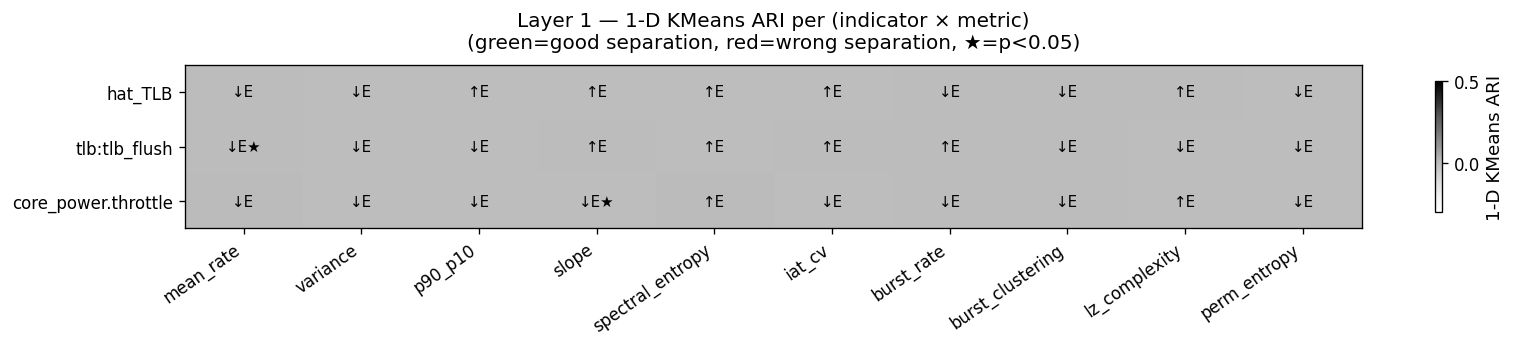

In [10]:
# Heatmap: indicator × metric, coloured by ARI, annotated with direction + star
l1_ok = l1_results[l1_results.status.ne('NOT IN DATA') & l1_results.status.ne('ALL ZERO')].copy()

if l1_ok.empty:
    print('No non-zero L1 features — nothing to plot.')
else:
    inds    = l1_ok['indicator'].unique().tolist()
    metrics = ALL_METRICS
    ari_grid = np.full((len(inds), len(metrics)), np.nan)
    dir_grid = np.full((len(inds), len(metrics)), '—', dtype=object)
    p_grid   = np.full((len(inds), len(metrics)), np.nan)

    for _, row in l1_ok.iterrows():
        if row['metric'] in metrics:
            i = inds.index(row['indicator'])
            j = metrics.index(row['metric'])
            ari_grid[i, j] = row['ari'] if pd.notna(row['ari']) else np.nan
            dir_grid[i, j] = row['direction']
            p_grid[i, j]   = row['p']

    ari_masked = np.ma.masked_invalid(ari_grid)
    fig, ax = plt.subplots(figsize=(14, max(3, len(inds) * 0.8)))
    im = ax.imshow(ari_masked, aspect='auto', cmap='Greys', vmin=-0.3, vmax=0.5)

    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, rotation=35, ha='right', fontsize=10)
    ax.set_yticks(range(len(inds)))
    ax.set_yticklabels(inds, fontsize=10)

    for i in range(len(inds)):
        for j in range(len(metrics)):
            d = dir_grid[i, j]
            star = '★' if pd.notna(p_grid[i,j]) and p_grid[i,j] < 0.05 else ''
            color = 'white' if (not np.isnan(ari_grid[i,j]) and abs(ari_grid[i,j]) > 0.25) else 'black'
            ax.text(j, i, f'{d}{star}', ha='center', va='center', fontsize=9, color=color)

    cbar = fig.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('1-D KMeans ARI', fontsize=11)
    ax.set_title('Layer 1 — 1-D KMeans ARI per (indicator × metric)\n'
                 '(green=good separation, red=wrong separation, ★=p<0.05)',
                 fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

## §8 — Layer 2: continuous performance metrics

Same analysis as Layer 1. These are PMU hardware counters and power/thermal
readings. They are not hardware anomaly events — they are continuous metrics
that deviate from normal when the hardware is under stress.

The two new indicators (`uncore_imc/cas_count_read/write/`) measure DRAM
transactions directly at the memory controller and are included here.

In [11]:
l2_results = analyse_indicator_group('Layer 2', HAT_L2, X_l2_raw)
print_summary_table(l2_results, 'Layer 2 — Continuous Performance Metrics')
l2_results.to_csv(RESULT_DIR / 'l2_results.csv', index=False)


  Layer 2 — Continuous Performance Metrics
  Indicator                                Metric                 NonZero    p-value  Dir     ARI  Mismatch
  --------------------------------------------------------------------------------------------------

  uncore_imc/cas_count_read/               mean_rate              480/480    0.7540    ↑E  -0.000       240
  uncore_imc/cas_count_read/               variance               480/480    0.0756    ↑E  -0.000       240
  uncore_imc/cas_count_read/               p90_p10                480/480    0.0974    ↑E  -0.000       240
  uncore_imc/cas_count_read/               slope                  480/480    0.0600    ↑E  -0.000       239
  uncore_imc/cas_count_read/               spectral_entropy       480/480    0.6801    ↓E  -0.000       239
  uncore_imc/cas_count_read/               burst_rate             480/480    0.2702    ↓E  -0.000       240
  uncore_imc/cas_count_read/               burst_clustering       480/480    0.4712    ↑E  -0.000 

### §8a — Layer 2: top features by 1-D KMeans mismatches

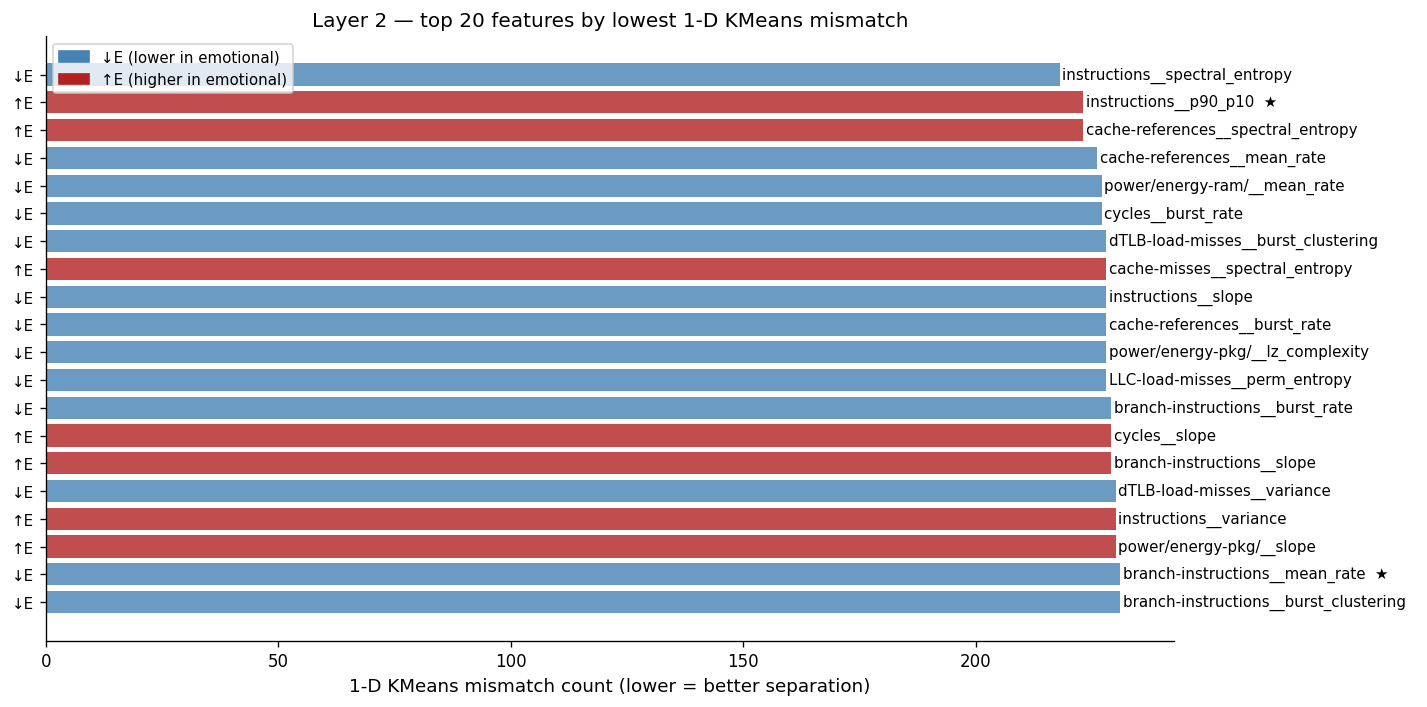


Significant (p<0.05): 2 / 99 tested


In [12]:
# Bar chart: top 20 Layer 2 (indicator, metric) pairs by lowest mismatch
l2_top = (l2_results
          .dropna(subset=['n_errors'])
          .sort_values(['n_errors', 'p'], ascending=[True, True])
          .head(20)
          .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['firebrick' if r['direction'] == '↑E' else 'steelblue'
          for _, r in l2_top.iterrows()]
bars = ax.barh(range(len(l2_top)), l2_top['n_errors'], color=colors, alpha=0.8)

for i, (_, row) in enumerate(l2_top.iterrows()):
    star = '★' if pd.notna(row['p']) and row['p'] < 0.05 else ''
    ax.text(row['n_errors'] + 0.6, i,
            f"{row['indicator']}__{row['metric']}  {star}",
            va='center', fontsize=9)

ax.set_yticks(range(len(l2_top)))
ax.set_yticklabels([f"{r['direction']}" for _, r in l2_top.iterrows()], fontsize=9)
ax.set_xlabel('1-D KMeans mismatch count (lower = better separation)', fontsize=11)
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)

n_patch = mpatches.Patch(color='steelblue', label='↓E (lower in emotional)')
e_patch = mpatches.Patch(color='firebrick', label='↑E (higher in emotional)')
ax.legend(handles=[n_patch, e_patch], fontsize=9)
plt.title('Layer 2 — top 20 features by lowest 1-D KMeans mismatch', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nSignificant (p<0.05): {(l2_results.p < 0.05).sum()} / {l2_results.p.notna().sum()} tested')

### §8b — Layer 2: heatmap (indicator × metric)

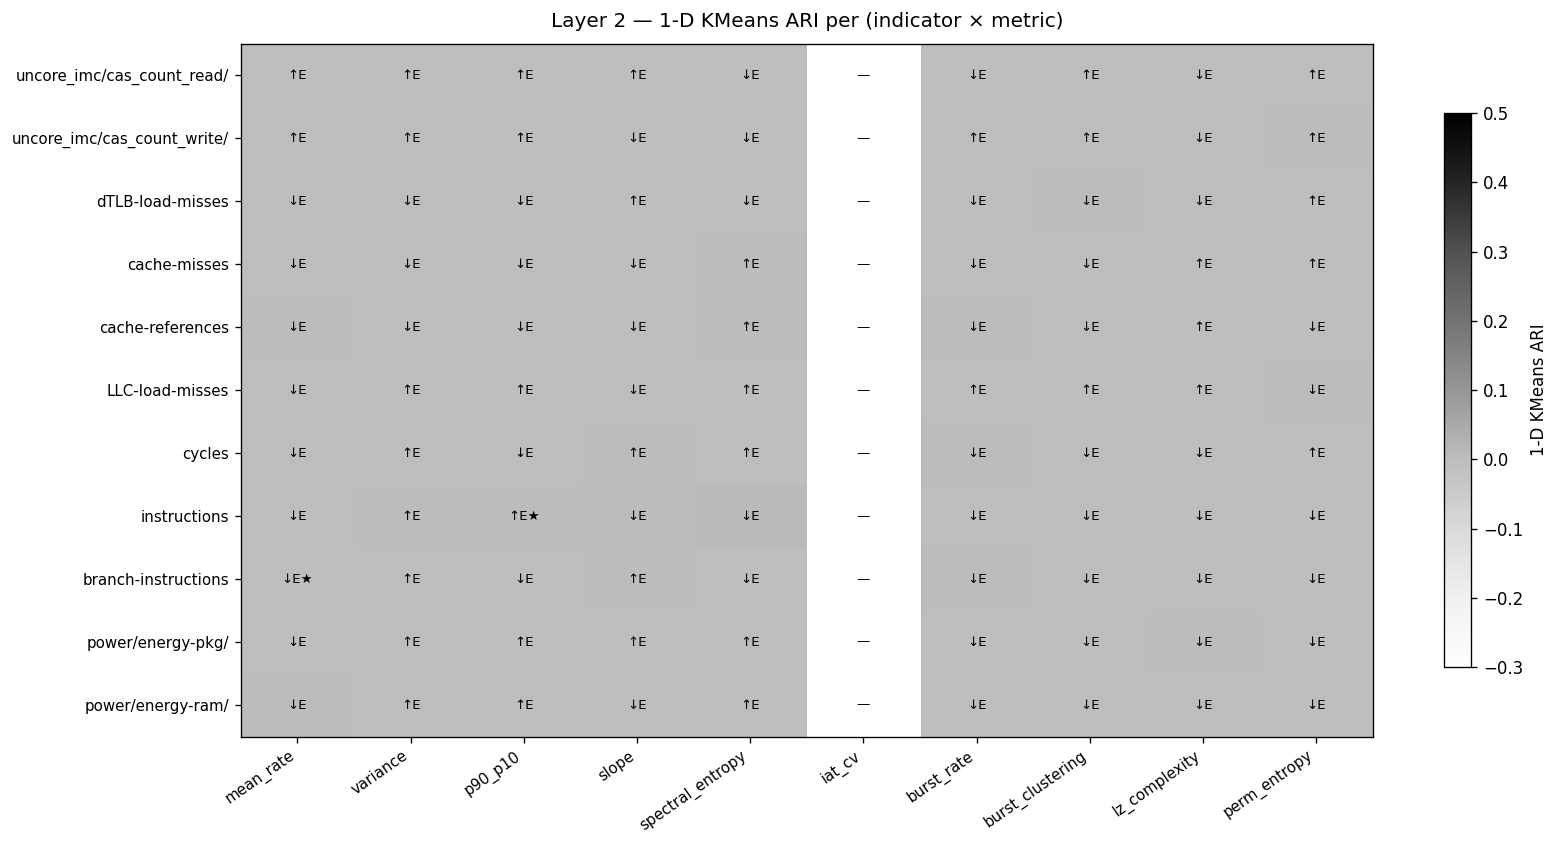

In [13]:
l2_ok = l2_results[l2_results.status.ne('NOT IN DATA') & l2_results.status.ne('ALL ZERO')].copy()

if not l2_ok.empty:
    inds    = l2_ok['indicator'].unique().tolist()
    metrics = ALL_METRICS
    ari_grid = np.full((len(inds), len(metrics)), np.nan)
    dir_grid = np.full((len(inds), len(metrics)), '—', dtype=object)
    p_grid   = np.full((len(inds), len(metrics)), np.nan)

    for _, row in l2_ok.iterrows():
        if row['metric'] in metrics:
            i = inds.index(row['indicator'])
            j = metrics.index(row['metric'])
            ari_grid[i, j] = row['ari'] if pd.notna(row['ari']) else np.nan
            dir_grid[i, j] = row['direction']
            p_grid[i, j]   = row['p']

    ari_masked = np.ma.masked_invalid(ari_grid)
    fig, ax = plt.subplots(figsize=(14, max(4, len(inds) * 0.65)))
    im = ax.imshow(ari_masked, aspect='auto', cmap='Greys', vmin=-0.3, vmax=0.5)

    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(inds)))
    ax.set_yticklabels(inds, fontsize=9)

    for i in range(len(inds)):
        for j in range(len(metrics)):
            d = dir_grid[i, j]
            star = '★' if pd.notna(p_grid[i,j]) and p_grid[i,j] < 0.05 else ''
            color = 'white' if (not np.isnan(ari_grid[i,j]) and abs(ari_grid[i,j]) > 0.25) else 'black'
            ax.text(j, i, f'{d}{star}', ha='center', va='center', fontsize=8, color=color)

    fig.colorbar(im, ax=ax, shrink=0.8).set_label('1-D KMeans ARI', fontsize=10)
    ax.set_title('Layer 2 — 1-D KMeans ARI per (indicator × metric)', fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

## §9 — Confounders (shown separately, not used in clustering)

These are collected for context but should not be interpreted as substrate signals.
If a confounder differs significantly between conditions, it may explain some of the
signal seen in L1/L2 features.

In [14]:
cf_results = analyse_indicator_group('Confounders', CONFOUNDERS, X_cf_raw)
print_summary_table(cf_results, 'Confounders — informational only, not used in clustering')

# Flag any significant confounders
sig_cf = cf_results[cf_results.p < 0.05]
if not sig_cf.empty:
    print(f'\n⚠  Significant confounders (p<0.05) — interpret L1/L2 results with caution:')
    for _, r in sig_cf.iterrows():
        print(f'   {r["indicator"]}__{r["metric"]}  p={r["p"]:.4f}  {r["direction"]}')
else:
    print('\n✓  No significant confounders.')


  Confounders — informational only, not used in clustering
  Indicator                                Metric                 NonZero    p-value  Dir     ARI  Mismatch
  --------------------------------------------------------------------------------------------------

  context-switches                         mean_rate              480/480    0.2989    ↓E  -0.000       231
  context-switches                         variance               480/480    0.6676    ↓E  -0.002       239
  context-switches                         p90_p10                480/480    0.4703    ↓E  -0.002       239
  context-switches                         slope                  480/480    0.5204    ↓E  -0.001       235
  context-switches                         spectral_entropy       480/480    0.3699    ↑E  -0.001       237
  context-switches                         burst_rate             480/480    0.3546    ↓E  -0.001       233
  context-switches                         burst_clustering       480/480    0.528

## §10 — Combined ranking: L1 + L2

Composite rank = average of p-value rank and mismatch rank across all L1 + L2 features.
This identifies the top candidates for the multi-feature clustering in §11.

In [15]:
combined = pd.concat([
    l1_results[l1_results.status.ne('NOT IN DATA') & l1_results.status.ne('ALL ZERO')],
    l2_results[l2_results.status.ne('NOT IN DATA') & l2_results.status.ne('ALL ZERO')],
], ignore_index=True).dropna(subset=['p', 'ari', 'n_errors'])

# Rank by p (ascending = better) and mismatch (ascending = better)
combined['p_rank']   = combined['p'].rank(ascending=True)
combined['err_rank'] = combined['n_errors'].rank(ascending=True)
combined['comp_rank'] = (combined['p_rank'] + combined['err_rank']) / 2
combined = combined.sort_values(['comp_rank', 'n_errors', 'p']).reset_index(drop=True)

print(f'Combined L1+L2 ranking — top {min(30, len(combined))} features:')
print(f'  {"Rank":<5} {"Layer":<7} {"Feature":<55} {"p-value":>10} {"Mismatch":>9} {"ARI":>8} {"Dir":>4}')
print(f'  {"-"*102}')
for i, (_, row) in enumerate(combined.head(30).iterrows()):
    layer = 'L1' if row['indicator'] in HAT_L1 else 'L2'
    feat  = f"{row['indicator']}__{row['metric']}"
    star  = '★' if row['p'] < 0.05 else ' '
    mismatch = f"{int(row['n_errors'])}" if pd.notna(row['n_errors']) else '—'
    print(f"  {i+1:<5} {layer:<7} {feat:<55} {row['p']:>9.4f}{star} {mismatch:>9} {row['ari']:>8.3f} {row['direction']:>4}")

print('Mismatch definition: points not assigned to the cluster where their true condition is the majority.')

combined.to_csv(RESULT_DIR / 'combined_ranking.csv', index=False)

Combined L1+L2 ranking — top 30 features:
  Rank  Layer   Feature                                                    p-value  Mismatch      ARI  Dir
  ------------------------------------------------------------------------------------------------------
  1     L2      instructions__p90_p10                                      0.0302★       223    0.003   ↑E
  2     L1      tlb:tlb_flush__burst_clustering                            0.0736        223    0.003   ↓E
  3     L1      hat_TLB__mean_rate                                         0.0593        227    0.001   ↓E
  4     L1      core_power.throttle__mean_rate                             0.0929        219    0.006   ↓E
  5     L2      dTLB-load-misses__burst_clustering                         0.0550        228    0.000   ↓E
  6     L1      core_power.throttle__spectral_entropy                      0.1292        220    0.005   ↑E
  7     L1      tlb:tlb_flush__slope                                       0.0773        227    0.001   

## §11 — Multi-feature clustering: top-N features (L1 + L2, no confounders)

We run k=2 KMeans on the top-ranked L1+L2 features.

Feature count selection is **automatic by default**:
- Search over `K = 1..TOP_N_SEARCH_MAX`
- Pick `TOP_N` that minimizes majority-cluster mismatches (`n_errors`)
- Tie-break by smaller K

**Mismatch definition:** number of points not assigned to the cluster where their true condition is the majority.

You can disable auto-selection in the next code cell and set a manual `TOP_N`.

Auto-selected TOP_N based on majority-cluster mismatches:
  TOP_N=6 (minimum mismatches=218)
Mismatch definition: points not assigned to the cluster where their true condition is the majority.
Top 6 features selected for n-D clustering:
  1. [L2] instructions__p90_p10
  2. [L1] tlb:tlb_flush__burst_clustering
  3. [L1] hat_TLB__mean_rate
  4. [L1] core_power.throttle__mean_rate
  5. [L2] dTLB-load-misses__burst_clustering
  6. [L1] core_power.throttle__spectral_entropy


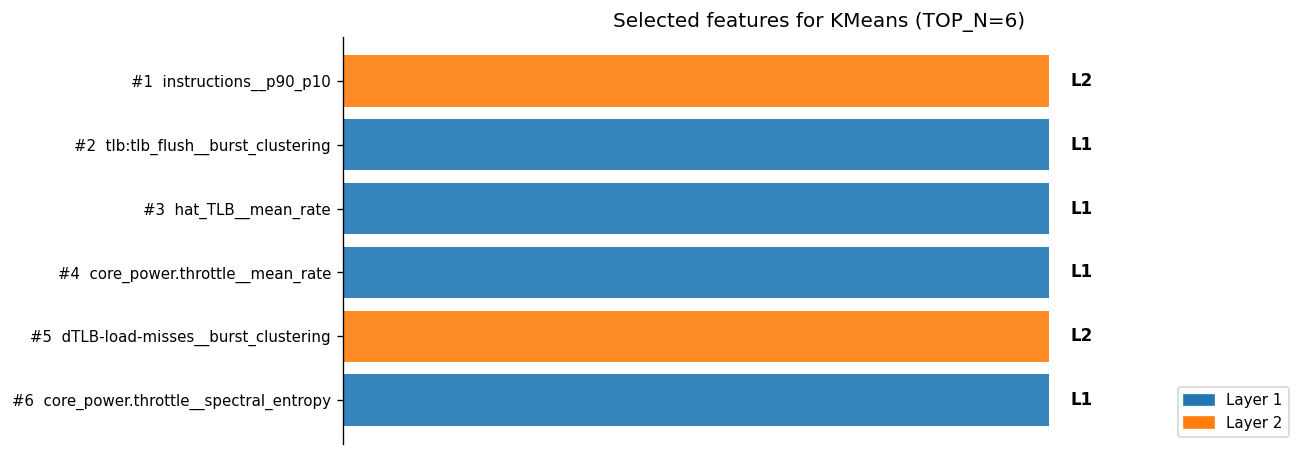

In [16]:
# Auto-select feature count by clustering quality (minimum majority-cluster mismatches)
AUTO_SELECT_TOP_N_BY_ERRORS = True
TOP_N_MANUAL = 4          # used only if auto-selection is disabled
TOP_N_SEARCH_MAX = 15     # max K tested when auto-selecting

# Merge L1 and L2 raw into one frame
all_raw = pd.concat([X_l1_raw, X_l2_raw], axis=1)

# Ranked candidate features from combined ranking (already excludes NOT IN DATA / ALL ZERO)
ranked_features = combined['col'].dropna().tolist()
ranked_features = [f for f in ranked_features if f in all_raw.columns]

if not ranked_features:
    raise ValueError('No ranked features available for clustering.')

if AUTO_SELECT_TOP_N_BY_ERRORS:
    K_max = min(TOP_N_SEARCH_MAX, len(ranked_features))
    K_vals_auto, ari_vals_auto, err_vals_auto = [], [], []

    for K in range(1, K_max + 1):
        cols_K = ranked_features[:K]
        X_K_raw = all_raw[cols_K].apply(pd.to_numeric, errors='coerce').fillna(all_raw[cols_K].median())
        X_K = StandardScaler().fit_transform(X_K_raw)

        km = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X_K)
        ari = adjusted_rand_score(y, km.labels_)

        cm = confusion_matrix(y, km.labels_)
        n_err = min(cm[0,1] + cm[1,0], cm[0,0] + cm[1,1])
        acc = 1 - n_err / cm.sum()

        K_vals_auto.append(K)
        ari_vals_auto.append(ari)
        err_vals_auto.append(int(n_err))

    auto_df = pd.DataFrame({'K': K_vals_auto, 'ARI': ari_vals_auto, 'n_errors': err_vals_auto})

    min_err = auto_df['n_errors'].min()
    best_candidates = auto_df[auto_df['n_errors'] == min_err].copy()
    best_candidates = best_candidates.sort_values(['K'], ascending=[True]).reset_index(drop=True)
    TOP_N = int(best_candidates.iloc[0]['K'])

    print('Auto-selected TOP_N based on majority-cluster mismatches:')
    print(f'  TOP_N={TOP_N} (minimum mismatches={min_err})')
    if len(best_candidates) > 1:
        print('  Tie on mismatches detected; tie-break applied: smaller K.')
else:
    TOP_N = min(TOP_N_MANUAL, len(ranked_features))
    print(f'Manual TOP_N selected: {TOP_N}')

print('Mismatch definition: points not assigned to the cluster where their true condition is the majority.')

# Build the combined feature matrix for selected TOP_N
top_features = ranked_features[:TOP_N]

print(f'Top {TOP_N} features selected for n-D clustering:')
for i, f in enumerate(top_features):
    layer = 'L1' if indicator_of(f) in HAT_L1 else 'L2'
    print(f'  {i+1}. [{layer}] {f}')

# ── Plot selected feature names + layer ──────────────────────────────────────
feat_layers = ['L1' if indicator_of(f) in HAT_L1 else 'L2' for f in top_features]
feat_df = pd.DataFrame({
    'feature': top_features,
    'layer': feat_layers,
    'rank': np.arange(1, len(top_features) + 1)
})

if not feat_df.empty:
    fig, ax = plt.subplots(figsize=(11, max(3.2, 0.65 * len(feat_df))))
    y_idx = np.arange(len(feat_df))
    colors = ['#1f77b4' if l == 'L1' else '#ff7f0e' for l in feat_df['layer']]

    ax.barh(y_idx, np.ones(len(feat_df)), color=colors, alpha=0.9)
    ax.set_yticks(y_idx)
    ax.set_yticklabels([f"#{r}  {f}" for r, f in zip(feat_df['rank'], feat_df['feature'])], fontsize=9)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_xlim(0, 1.35)
    ax.set_title(f'Selected features for KMeans (TOP_N={TOP_N})', fontsize=12)

    for i, layer in enumerate(feat_df['layer']):
        ax.text(1.03, i, layer, va='center', fontsize=10, fontweight='bold')

    l1_patch = mpatches.Patch(color='#1f77b4', label='Layer 1')
    l2_patch = mpatches.Patch(color='#ff7f0e', label='Layer 2')
    ax.legend(handles=[l1_patch, l2_patch], loc='lower right', fontsize=9)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    plt.tight_layout()
    plt.show()

X_top_raw = all_raw[top_features].apply(pd.to_numeric, errors='coerce').fillna(all_raw[top_features].median())
scaler_top = StandardScaler()
X_top = scaler_top.fit_transform(X_top_raw)

### §11a — n-D KMeans k=2 result

n-D KMeans k=2 for top 6 features:
  ARI                         : 0.0064
  Accuracy                    : 0.5458
  Majority-cluster mismatches : 218 out of 480
  Best 1-D ARI                : 0.0068  (single feature baseline)
  Improvement                 : -0.0004
  Definition                  : mismatch = point not assigned to the cluster where its true condition is majority


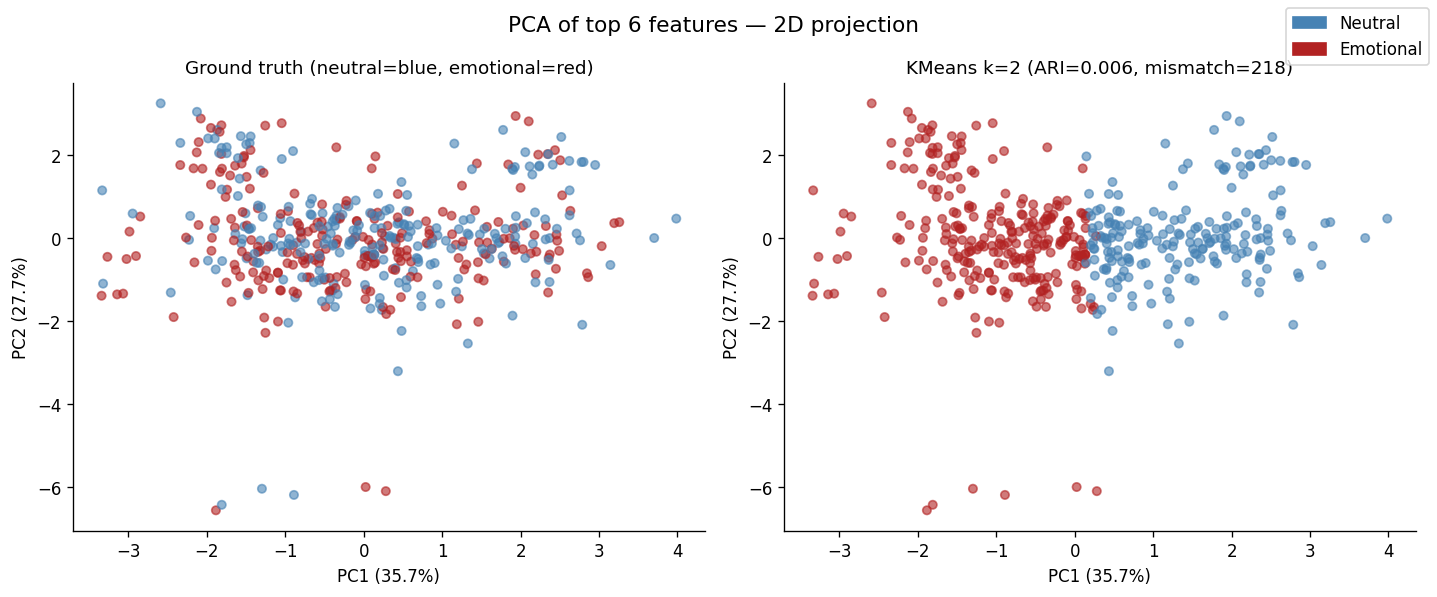

In [17]:
km_nd = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X_top)
labels_nd = km_nd.labels_

ari_nd  = adjusted_rand_score(y, labels_nd)
cm_nd   = confusion_matrix(y, labels_nd)
n_err_nd = min(cm_nd[0,1] + cm_nd[1,0], cm_nd[0,0] + cm_nd[1,1])
acc_nd  = 1 - n_err_nd / cm_nd.sum()

print(f'n-D KMeans k=2 for top {TOP_N} features:')
print(f'  ARI                         : {ari_nd:.4f}')
print(f'  Accuracy                    : {acc_nd:.4f}')
print(f'  Majority-cluster mismatches : {int(n_err_nd)} out of {len(y)}')
print(f'  Best 1-D ARI                : {combined.ari.max():.4f}  (single feature baseline)')
print(f'  Improvement                 : {ari_nd - combined.ari.max():.4f}')
print('  Definition                  : mismatch = point not assigned to the cluster where its true condition is majority')

# PCA scatter
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_top)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, labels, title in [
        (axes[0], y,        'Ground truth (neutral=blue, emotional=red)'),
        (axes[1], labels_nd, f'KMeans k=2 (ARI={ari_nd:.3f}, mismatch={int(n_err_nd)})')]:
    colors = ['steelblue' if l == 0 else 'firebrick' for l in labels]
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, s=25)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.set_title(title, fontsize=11)
    ax.spines[['top','right']].set_visible(False)

n_p = mpatches.Patch(color='steelblue', label='Neutral')
e_p = mpatches.Patch(color='firebrick', label='Emotional')
fig.legend(handles=[n_p, e_p], loc='upper right', fontsize=10)
plt.suptitle(f'PCA of top {TOP_N} features — 2D projection', fontsize=13)
plt.tight_layout()
plt.show()

### §11a-b — n-D KMeans using only top Layer 1 features

This is the same KMeans workflow as §11a, but restricted to Layer 1 features only.
It shows whether anomaly-layer signals alone can separate neutral vs emotional trials.

Feature count selection is **automatic by default**:
- Search over `K = 1..TOP_N_L1_SEARCH_MAX`
- Pick `TOP_N_L1` that minimizes majority-cluster mismatches (`n_errors`)
- Tie-break by smaller K

**Mismatch definition:** number of points not assigned to the cluster where their true condition is the majority.

Auto-selected TOP_N_L1 based on majority-cluster mismatches:
  TOP_N_L1=10 (minimum mismatches=217)
Mismatch definition: points not assigned to the cluster where their true condition is the majority.

L1-only KMeans results for all N:
 N       ARI   Accuracy   Mismatch  Features
------------------------------------------------------------------------------------------------------------------------
 1    0.0030     0.5354        223  tlb:tlb_flush__burst_clustering
 2    0.0011     0.5271        227  tlb:tlb_flush__burst_clustering, core_power.throttle__mean_rate
 3   -0.0010     0.5167        232  tlb:tlb_flush__burst_clustering, core_power.throttle__mean_rate, hat_TLB__mean_rate
 4    0.0020     0.5312        225  tlb:tlb_flush__burst_clustering, core_power.throttle__mean_rate, hat_TLB__mean_rate, tlb:tlb_flush__slope
 5    0.0010     0.5271        227  tlb:tlb_flush__burst_clustering, core_power.throttle__mean_rate, hat_TLB__mean_rate, tlb:tlb_flush__slope, tlb:tlb_flush__mean_rate
 

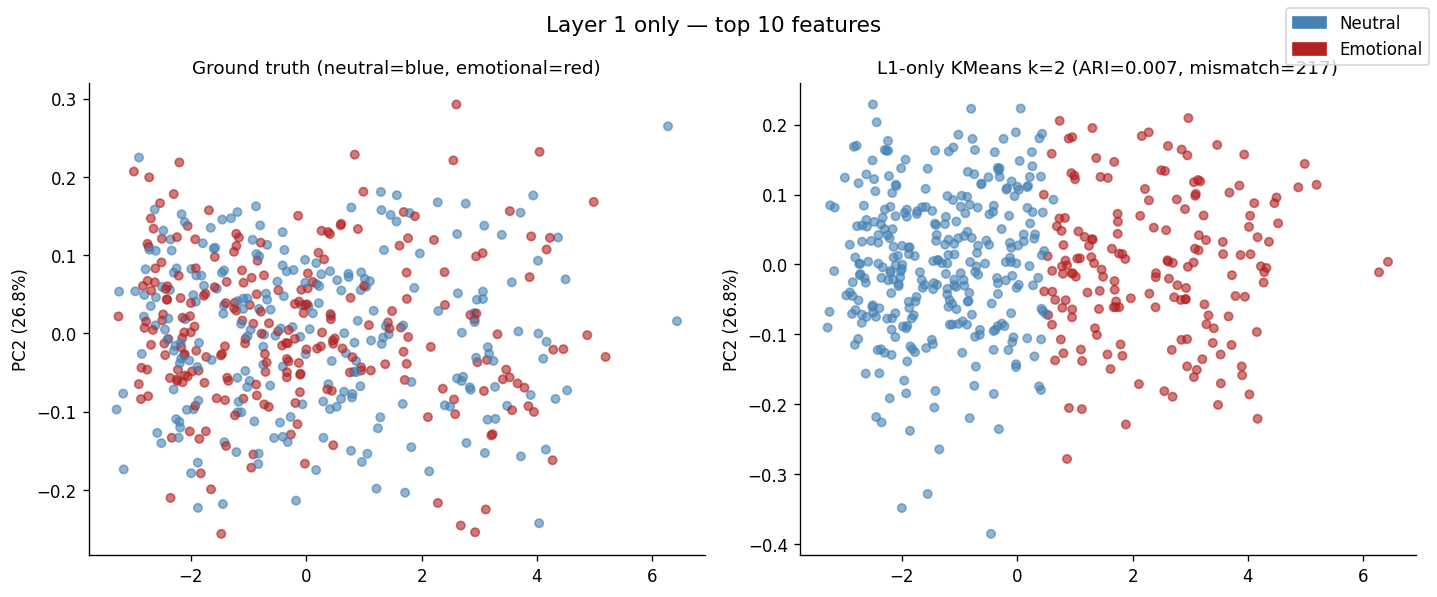

In [18]:
# Build Layer-1-only ranking and run KMeans on top-N L1 features
l1_only = l1_results[l1_results.status.ne('NOT IN DATA') & l1_results.status.ne('ALL ZERO')].dropna(subset=['p', 'ari', 'n_errors']).copy()
y_true = (df_all['condition'] == 'emotional').astype(int).values

AUTO_SELECT_TOP_N_L1_BY_ERRORS = True
TOP_N_L1_MANUAL = TOP_N
TOP_N_L1_SEARCH_MAX = 15

if l1_only.empty:
    print('No usable Layer 1 features for L1-only KMeans.')
else:
    l1_only['p_rank'] = l1_only['p'].rank(ascending=True)
    l1_only['err_rank'] = l1_only['n_errors'].rank(ascending=True)
    l1_only['comp_rank'] = (l1_only['p_rank'] + l1_only['err_rank']) / 2
    l1_only = l1_only.sort_values(['comp_rank', 'n_errors', 'p']).reset_index(drop=True)

    l1_ranked_features = l1_only['col'].dropna().tolist()
    l1_ranked_features = [f for f in l1_ranked_features if f in X_l1_raw.columns]

    if not l1_ranked_features:
        print('No valid Layer 1 feature columns found after filtering.')
    else:
        # Full L1-only sweep report across all N
        K_max_l1 = min(TOP_N_L1_SEARCH_MAX, len(l1_ranked_features))
        rows_l1 = []

        for K in range(1, K_max_l1 + 1):
            cols_K = l1_ranked_features[:K]
            X_K_raw = X_l1_raw[cols_K].apply(pd.to_numeric, errors='coerce').fillna(X_l1_raw[cols_K].median())
            X_K = StandardScaler().fit_transform(X_K_raw)

            km = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X_K)
            ari = adjusted_rand_score(y_true, km.labels_)

            cm = confusion_matrix(y_true, km.labels_)
            n_err = min(cm[0,1] + cm[1,0], cm[0,0] + cm[1,1])
            acc = 1 - n_err / cm.sum()

            rows_l1.append({
                'N': K,
                'ARI': ari,
                'accuracy': acc,
                'mismatch': int(n_err),
                'features': ', '.join(cols_K)
            })

        l1_sweep_df = pd.DataFrame(rows_l1)

        # Selection rule
        best_l1_rows = l1_sweep_df[l1_sweep_df['mismatch'] == l1_sweep_df['mismatch'].min()].copy()
        best_l1_rows = best_l1_rows.sort_values(['N'], ascending=[True]).reset_index(drop=True)

        if AUTO_SELECT_TOP_N_L1_BY_ERRORS:
            TOP_N_L1 = int(best_l1_rows.iloc[0]['N'])
            print('Auto-selected TOP_N_L1 based on majority-cluster mismatches:')
            print(f"  TOP_N_L1={TOP_N_L1} (minimum mismatches={int(best_l1_rows.iloc[0]['mismatch'])})")
            if len(best_l1_rows) > 1:
                print('  Tie on mismatches detected; tie-break applied: smaller N.')
        else:
            TOP_N_L1 = min(TOP_N_L1_MANUAL, len(l1_ranked_features))
            print(f'Manual TOP_N_L1 selected: {TOP_N_L1}')

        print('Mismatch definition: points not assigned to the cluster where their true condition is the majority.')
        print()
        print('L1-only KMeans results for all N:')
        print(f"{'N':>2}  {'ARI':>8}  {'Accuracy':>9}  {'Mismatch':>9}  Features")
        print('-' * 120)
        for _, r in l1_sweep_df.iterrows():
            marker = '  ← selected' if int(r['N']) == TOP_N_L1 else ''
            print(f"{int(r['N']):>2}  {r['ARI']:>8.4f}  {r['accuracy']:>9.4f}  {int(r['mismatch']):>9}  {r['features']}{marker}")

        l1_top_features = l1_ranked_features[:TOP_N_L1]

        print(f'\nL1-only KMeans uses top {len(l1_top_features)} Layer 1 features:')
        for i, f in enumerate(l1_top_features):
            print(f'  {i+1}. {f}')

        X_l1_top_raw = X_l1_raw[l1_top_features].apply(pd.to_numeric, errors='coerce').fillna(X_l1_raw[l1_top_features].median())
        X_l1_top = StandardScaler().fit_transform(X_l1_top_raw)

        km_l1 = KMeans(n_clusters=2, n_init=50, random_state=42).fit(X_l1_top)
        labels_l1 = km_l1.labels_

        ari_l1 = adjusted_rand_score(y_true, labels_l1)
        cm_l1 = confusion_matrix(y_true, labels_l1)
        err_l1 = min(cm_l1[0,1] + cm_l1[1,0], cm_l1[0,0] + cm_l1[1,1])
        acc_l1 = 1 - err_l1 / cm_l1.sum()

        print(f'\nL1-only n-D KMeans k=2 (using selected N):')
        print(f'  ARI                         : {ari_l1:.4f}')
        print(f'  Accuracy                    : {acc_l1:.4f}')
        print(f'  Majority-cluster mismatches : {int(err_l1)} out of {len(y_true)}')

        # PCA scatter for L1-only model
        n_pca_l1 = min(2, X_l1_top.shape[1])
        pca_l1 = PCA(n_components=n_pca_l1, random_state=42)
        X_l1_pca = pca_l1.fit_transform(X_l1_top)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, labels, title in [
                (axes[0], y_true, 'Ground truth (neutral=blue, emotional=red)'),
                (axes[1], labels_l1, f'L1-only KMeans k=2 (ARI={ari_l1:.3f}, mismatch={int(err_l1)})')]:
            colors = ['steelblue' if l == 0 else 'firebrick' for l in labels]
            noise = np.random.normal(0, 0.1, size=X_l1_pca.shape[0])
            ax.scatter(
                X_l1_pca[:, 0],                  # x = PC1
                noise,          # y = PC2 + noise
                c=colors,
                alpha=0.6,
                s=25
            )            
            ax.set_ylabel(f'PC2 ({pca_l1.explained_variance_ratio_[1]*100:.1f}%)')
            ax.set_title(title, fontsize=11)
            ax.spines[['top','right']].set_visible(False)

        n_p = mpatches.Patch(color='steelblue', label='Neutral')
        e_p = mpatches.Patch(color='firebrick', label='Emotional')
        fig.legend(handles=[n_p, e_p], loc='upper right', fontsize=10)
        plt.suptitle(f'Layer 1 only — top {len(l1_top_features)} features', fontsize=13)
        plt.tight_layout()
        plt.show()

### §11b — K-sweep: how do ARI and majority-cluster mismatches scale with N features?

In [19]:
# Sweep K from 1 to min(15, available) — print full KMeans results per N (no plot)
all_cols_ranked = combined['col'].dropna().tolist()
all_cols_ranked = [c for c in all_cols_ranked if c in all_raw.columns]
K_max = min(15, len(all_cols_ranked))

rows = []
for K in range(1, K_max + 1):
    cols_K = all_cols_ranked[:K]
    X_K = all_raw[cols_K].apply(pd.to_numeric, errors='coerce').fillna(all_raw[cols_K].median())
    X_K = StandardScaler().fit_transform(X_K)

    km = KMeans(n_clusters=2, n_init=20, random_state=42).fit(X_K)
    ari = adjusted_rand_score(y, km.labels_)

    cm = confusion_matrix(y, km.labels_)
    n_err = min(cm[0,1] + cm[1,0], cm[0,0] + cm[1,1])
    acc = 1 - n_err / cm.sum()

    rows.append({
        'N': K,
        'ARI': ari,
        'accuracy': acc,
        'mismatch': int(n_err),
        'features': ', '.join(cols_K)
    })

sweep_df = pd.DataFrame(rows)

# Choose best-N by minimum mismatches (tie-break: smaller N)
best_rows = sweep_df[sweep_df['mismatch'] == sweep_df['mismatch'].min()].copy()
best_rows = best_rows.sort_values(['N'], ascending=[True]).reset_index(drop=True)
best_N = int(best_rows.iloc[0]['N'])

print('KMeans results for all N (L1+L2, k=2):')
print('Mismatch definition: points not assigned to the cluster where their true condition is the majority.')
print()

print(f"{'N':>2}  {'ARI':>8}  {'Accuracy':>9}  {'Mismatch':>9}  Features")
print('-' * 120)
for _, r in sweep_df.iterrows():
    marker = '  ← selected' if int(r['N']) == best_N else ''
    print(f"{int(r['N']):>2}  {r['ARI']:>8.4f}  {r['accuracy']:>9.4f}  {int(r['mismatch']):>9}  {r['features']}{marker}")

print('\nBest N by minimum mismatch:')
print(f"  N={best_N}  ARI={best_rows.iloc[0]['ARI']:.4f}  accuracy={best_rows.iloc[0]['accuracy']:.4f}  mismatch={int(best_rows.iloc[0]['mismatch'])}/{len(y)}")
if len(best_rows) > 1:
    print('  Note: multiple N had same minimum mismatch; chose smaller N.')

KMeans results for all N (L1+L2, k=2):
Mismatch definition: points not assigned to the cluster where their true condition is the majority.

 N       ARI   Accuracy   Mismatch  Features
------------------------------------------------------------------------------------------------------------------------
 1    0.0030     0.5354        223  instructions__p90_p10
 2    0.0030     0.5354        223  instructions__p90_p10, tlb:tlb_flush__burst_clustering
 3    0.0030     0.5354        223  instructions__p90_p10, tlb:tlb_flush__burst_clustering, hat_TLB__mean_rate
 4   -0.0007     0.5188        231  instructions__p90_p10, tlb:tlb_flush__burst_clustering, hat_TLB__mean_rate, core_power.throttle__mean_rate
 5    0.0024     0.5333        224  instructions__p90_p10, tlb:tlb_flush__burst_clustering, hat_TLB__mean_rate, core_power.throttle__mean_rate, dTLB-load-misses__burst_clustering
 6    0.0064     0.5458        218  instructions__p90_p10, tlb:tlb_flush__burst_clustering, hat_TLB__mean_rate, 

## §12 — Summary

In [20]:
print('='*80)
print('ANALYSIS SUMMARY')
print('='*80)
print(f'Trials: {len(df_all)} ({len(RUNS_LOADED)} runs)')
print(f'Elapsed_ms balanced: {"YES" if not LENGTH_CONFOUNDED else "NO — length confound present"}')
print()

print('Layer 1 — HAT Hardware Anomaly Indicators:')
for ind, desc in HAT_L1.items():
    ind_cols = [c for c in X_l1_raw.columns if indicator_of(c) == ind or c.startswith(ind+'__')]
    if not ind_cols:
        print(f'  {ind:<45} NOT IN DATA')
        continue
    any_nz = (X_l1_raw[ind_cols].apply(pd.to_numeric,errors='coerce').abs()>1e-9).any(axis=1).sum()
    best = l1_results[l1_results.indicator == ind].dropna(subset=['p']).sort_values('p')
    if best.empty or any_nz == 0:
        print(f'  {ind:<45} ALL ZERO (healthy node)')
    else:
        r = best.iloc[0]
        star = '★' if r.p < 0.05 else ''
        print(f'  {ind:<45} non-zero={any_nz}/{len(df_all)}  best: {r.metric}  p={r.p:.4f}{star}  ARI={r.ari:.3f}  {r.direction}')

print()
print('Layer 2 — top 5 features:')
for i, (_, row) in enumerate(combined[combined.indicator.isin(HAT_L2)].head(5).iterrows()):
    star = '★' if row.p < 0.05 else ''
    print(f'  {i+1}. {row.indicator}__{row.metric}  p={row.p:.4f}{star}  ARI={row.ari:.3f}  {row.direction}')

print()
print(f'Multi-feature KMeans (top {TOP_N}):')
print(f'  ARI                           = {ari_nd:.4f}')
print(f'  Accuracy                      = {acc_nd:.4f}')
print(f'  Majority-cluster mismatches   = {n_err_nd}/{len(y)}')
print(f'  Best single-feature ARI       = {combined.ari.max():.4f}')
print(f'  Gain from combining features  = {ari_nd - combined.ari.max():.4f}')
print('  Mismatch definition           = points not assigned to the cluster where their true condition is the majority')

ANALYSIS SUMMARY
Trials: 480 (12 runs)
Elapsed_ms balanced: YES

Layer 1 — HAT Hardware Anomaly Indicators:
  hat_SPU                                       NOT IN DATA
  hat_MCE                                       NOT IN DATA
  hat_TLB                                       non-zero=480/480  best: mean_rate  p=0.0593  ARI=0.001  ↓E
  tlb:tlb_flush                                 non-zero=480/480  best: mean_rate  p=0.0312★  ARI=0.000  ↓E
  mce:mce_record                                NOT IN DATA
  core_power.throttle                           non-zero=480/480  best: slope  p=0.0466★  ARI=-0.000  ↓E
  uncore_imc/UNC_M_ECC_CORRECTABLE_ERRORS/      NOT IN DATA

Layer 2 — top 5 features:
  1. instructions__p90_p10  p=0.0302★  ARI=0.003  ↑E
  2. dTLB-load-misses__burst_clustering  p=0.0550  ARI=0.000  ↓E
  3. cache-references__spectral_entropy  p=0.1299  ARI=0.003  ↑E
  4. branch-instructions__mean_rate  p=0.0269★  ARI=-0.001  ↓E
  5. dTLB-load-misses__variance  p=0.0663  ARI=-0.000  ↓E

